# Keyboard Dynamics pour la detection de Parkinson avec NeuroQWERTY

Ce notebook construit une baseline experimentale pour la modalite **Keyboard Dynamics** a partir du dataset NeuroQWERTY MIT-CS1PD / MIT-CS2PD. Il reprend l'esprit du papier recent base sur des features statistiques, PSO, Random Forest et classifieurs d'ensemble, mais l'adapte au dataset brut disponible localement.

Objectifs:
- charger les fichiers bruts de frappe sans utiliser le loader legacy Python 2;
- construire une table session-level propre;
- faire une EDA lisible;
- entrainer plusieurs modeles avec validation groupee par sujet;
- selectionner les features avec Binary PSO;
- sauvegarder un pipeline reutilisable pour une future app locale ou web.

Important: ce notebook est un prototype de recherche/hackathon, pas un outil de diagnostic clinique.

## 1. Configuration

Le dataset local contient deux sous-ensembles:
- `MIT-CS1PD`: early Parkinson, 31 sujets, deux repetitions possibles;
- `MIT-CS2PD`: de-novo Parkinson, 54 sujets, une repetition.

On utilise `StratifiedGroupKFold` pour conserver l'equilibre des classes tout en evitant qu'un meme participant apparaisse dans train et validation.

In [1]:
from pathlib import Path
import json
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from pyswarms.discrete import BinaryPSO
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0").exists() and ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_ROOT = ROOT / "data" / "neuroqwerty-mit-csxpd-dataset-1.0.0"
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Dataset root exists: {DATA_ROOT.exists()} -> {DATA_ROOT}")

Project root: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection
Dataset root exists: True -> /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/data/neuroqwerty-mit-csxpd-dataset-1.0.0


## 2. Chargement Python 3 des fichiers bruts

Les CSV bruts ont quatre colonnes sans header:

`key, hold_time, release_time, press_time`

Les noms de touches sont conserves pour le filtrage. Les features de modele sont calculees uniquement a partir des timings.

In [2]:
KEY_COLUMNS = ["key", "hold_time", "release_time", "press_time"]

MOUSE_RE = re.compile(r'"?mouse.+"?', re.IGNORECASE)
LONG_META_RE = re.compile(r'"?(Shift.+|Alt.+|Control.+)"?', re.IGNORECASE)
BACKSPACE_RE = re.compile(r'"?BackSpace"?', re.IGNORECASE)


def load_keystroke_csv(path: Path) -> pd.DataFrame:
    """Load one NeuroQWERTY raw file using the documented column order."""
    df = pd.read_csv(path, header=None, names=KEY_COLUMNS)
    df["key"] = df["key"].astype(str).str.strip()
    for col in ["hold_time", "release_time", "press_time"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def clean_keystrokes(df: pd.DataFrame) -> pd.DataFrame:
    """Filter invalid timings and non-informative keys, following the original loader intent."""
    before = len(df)
    clean = df.dropna(subset=["hold_time", "release_time", "press_time"]).copy()

    key = clean["key"].astype(str)
    keep = ~key.str.match(MOUSE_RE)
    keep &= ~key.str.match(LONG_META_RE)
    keep &= ~key.str.match(BACKSPACE_RE)
    clean = clean.loc[keep].copy()

    clean = clean[(clean["press_time"] > 0) & (clean["release_time"] > 0)]
    clean = clean[(clean["hold_time"] >= 0) & (clean["hold_time"] < 5)]
    clean = clean.sort_values("press_time").reset_index(drop=True)

    clean["flight_time"] = clean["press_time"].diff()
    clean.loc[clean["flight_time"] < 0, "flight_time"] = np.nan

    clean.attrs["rows_before_cleaning"] = before
    clean.attrs["rows_after_cleaning"] = len(clean)
    return clean


def safe_ratio(numerator: float, denominator: float) -> float:
    if denominator is None or np.isnan(denominator) or abs(denominator) < 1e-12:
        return np.nan
    return numerator / denominator


def iqr(series: pd.Series) -> float:
    return series.quantile(0.75) - series.quantile(0.25)


def session_features(df: pd.DataFrame) -> dict:
    """Aggregate one cleaned keystroke session into session-level features."""
    ht = df["hold_time"].dropna()
    ft = df["flight_time"].dropna()
    duration = df["release_time"].max() - df["press_time"].min() if len(df) else np.nan
    mean_hold = ht.mean()
    mean_flight = ft.mean()

    return {
        "n_keystrokes": len(df),
        "session_duration_sec": duration,
        "typing_speed_keys_per_min": safe_ratio(len(df) * 60, duration),
        "mean_hold_time": mean_hold,
        "std_hold_time": ht.std(ddof=1),
        "median_hold_time": ht.median(),
        "iqr_hold_time": iqr(ht),
        "q10_hold_time": ht.quantile(0.10),
        "q90_hold_time": ht.quantile(0.90),
        "mean_flight_time": mean_flight,
        "std_flight_time": ft.std(ddof=1),
        "median_flight_time": ft.median(),
        "iqr_flight_time": iqr(ft),
        "q10_flight_time": ft.quantile(0.10),
        "q90_flight_time": ft.quantile(0.90),
        "hold_to_flight_ratio": safe_ratio(mean_hold, mean_flight),
    }


def build_session_table(data_root: Path) -> pd.DataFrame:
    rows = []
    for dataset in ["MIT-CS1PD", "MIT-CS2PD"]:
        gt_path = data_root / dataset / f"GT_DataPD_{dataset}.csv"
        raw_dir = data_root / dataset / f"data_{dataset}"
        gt = pd.read_csv(gt_path)
        file_cols = [col for col in gt.columns if col.startswith("file_")]

        for _, subject in gt.iterrows():
            for file_col in file_cols:
                file_name = subject.get(file_col)
                if pd.isna(file_name) or not str(file_name).strip():
                    continue
                file_path = raw_dir / str(file_name)
                raw = load_keystroke_csv(file_path)
                clean = clean_keystrokes(raw)
                feats = session_features(clean)
                rows.append({
                    "dataset": dataset,
                    "pID": int(subject["pID"]),
                    "session_file": str(file_name),
                    "session_id": file_col,
                    "gt": bool(subject["gt"]),
                    "label": int(bool(subject["gt"])),
                    "rows_before_cleaning": clean.attrs.get("rows_before_cleaning"),
                    "rows_after_cleaning": clean.attrs.get("rows_after_cleaning"),
                    **feats,
                })
    return pd.DataFrame(rows)

sessions = build_session_table(DATA_ROOT)
sessions.head()

,dataset,pID,session_file,session_id,gt,label,rows_before_cleaning,rows_after_cleaning,n_keystrokes,session_duration_sec,...,iqr_hold_time,q10_hold_time,q90_hold_time,mean_flight_time,std_flight_time,median_flight_time,iqr_flight_time,q10_flight_time,q90_flight_time,hold_to_flight_ratio
0,MIT-CS1PD,11,1402930351.011_001_014.csv,file_1,True,1,2529,2456,2456,717.3391,...,0.051225,0.06980,0.17135,0.292093,0.301811,0.22920,0.117750,0.12902,0.49060,0.369161
1,MIT-CS1PD,11,1403706430.011_003_014.csv,file_2,True,1,2538,2485,2485,730.6452,...,0.056800,0.06694,0.17854,0.294107,0.505961,0.22845,0.120625,0.12709,0.43654,0.365209
2,MIT-CS1PD,60,1402932300.060_001_014.csv,file_1,False,0,914,884,884,900.3389,...,0.049400,0.07881,0.17070,1.019554,1.047391,0.66670,0.777000,0.31562,2.02282,0.122722
3,MIT-CS1PD,60,1403708258.060_003_014.csv,file_2,False,0,950,939,939,899.5378,...,0.048500,0.07776,0.17190,0.958841,0.980078,0.63815,0.724150,0.33848,1.93070,0.130715
4,MIT-CS1PD,67,1401117235.067_001_014.csv,file_1,True,1,824,813,813,897.9630,...,0.099400,0.11400,0.31856,1.105704,1.367207,0.64995,0.520650,0.38434,2.28071,0.175214


In [3]:
print(f"Sessions: {len(sessions)}")
print(f"Subjects: {sessions['pID'].nunique()}")
display(sessions.groupby(["dataset", "label"]).size().rename("n_sessions").reset_index())
display(sessions.groupby("dataset")["pID"].nunique().rename("n_subjects").reset_index())

Sessions: 116
Subjects: 85


,dataset,label,n_sessions
0,MIT-CS1PD,0,26
1,MIT-CS1PD,1,36
2,MIT-CS2PD,0,30
3,MIT-CS2PD,1,24


,dataset,n_subjects
0,MIT-CS1PD,31
1,MIT-CS2PD,54


### Lecture rapide de la volumetrie

Le notebook reconstruit **116 sessions** a partir de **85 sujets**. La repartition est legerement desequilibree mais exploitable: 56 sessions controle et 60 sessions Parkinson. MIT-CS1PD contient deux repetitions par sujet, alors que MIT-CS2PD n'en contient qu'une; c'est la raison principale pour laquelle on valide par groupe `pID` au lieu de melanger les lignes au hasard.

Point important: une session n'est pas un sujet independant. Sans validation groupee, les deux repetitions d'un meme participant MIT-CS1PD pourraient se retrouver a la fois dans l'entrainement et dans le test, ce qui gonflerait artificiellement les scores.

## 3. EDA

Cette section sert a comprendre la structure du dataset, la distribution des classes, les valeurs aberrantes et les relations entre features avant toute modelisation.

2026-05-06 15:49:37,019 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,021 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,032 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,035 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


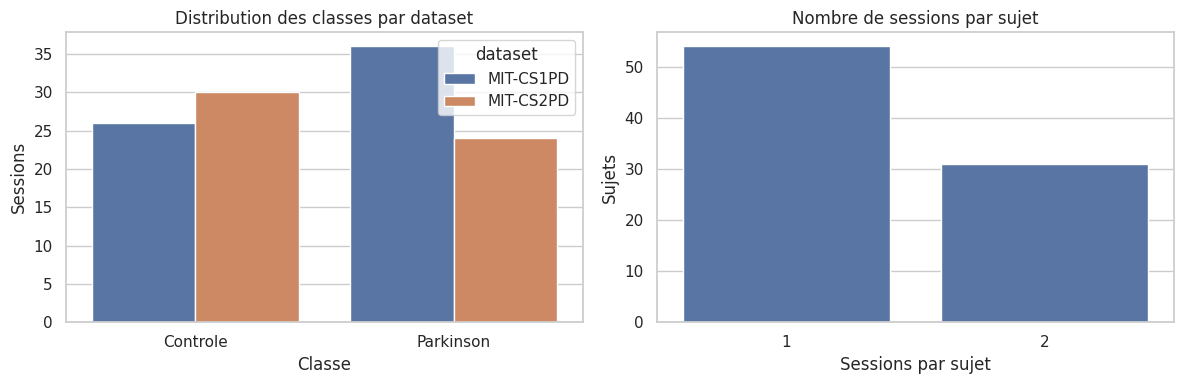

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=sessions, x="label", hue="dataset", ax=axes[0])
axes[0].set_title("Distribution des classes par dataset")
axes[0].set_xticklabels(["Controle", "Parkinson"])
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Sessions")

session_counts = sessions.groupby("pID").size().rename("n_sessions").reset_index()
sns.countplot(data=session_counts, x="n_sessions", ax=axes[1])
axes[1].set_title("Nombre de sessions par sujet")
axes[1].set_xlabel("Sessions par sujet")
axes[1].set_ylabel("Sujets")
plt.tight_layout()
plt.show()

### Interpretation des distributions de sessions

La figure confirme deux choses utiles pour la suite:

- les classes restent assez proches en nombre de sessions, donc le probleme n'est pas fortement desequilibre;
- certains sujets ont deux sessions, ce qui rend le controle anti-fuite indispensable.

Pour un hackathon, cette volumetrie est suffisante pour construire une baseline et comparer des approches, mais elle reste trop petite pour conclure cliniquement. Les scores doivent donc etre lus comme une estimation experimentale, pas comme une performance generalisable.

In [5]:
feature_cols = [
    "mean_hold_time", "std_hold_time", "mean_flight_time", "std_flight_time",
    "hold_to_flight_ratio", "n_keystrokes", "session_duration_sec",
    "typing_speed_keys_per_min", "median_hold_time", "iqr_hold_time",
    "median_flight_time", "iqr_flight_time", "q10_hold_time", "q90_hold_time",
    "q10_flight_time", "q90_flight_time",
]

summary = sessions[feature_cols].describe().T
summary["missing"] = sessions[feature_cols].isna().sum()
display(summary)

,count,mean,std,min,25%,50%,75%,max,missing
mean_hold_time,116.0,0.123786,0.039045,0.052545,0.092351,0.118846,0.151769,0.236820,0
std_hold_time,116.0,0.052438,0.052997,0.012436,0.026771,0.038364,0.053664,0.353915,0
mean_flight_time,116.0,0.751262,0.550411,0.214561,0.441713,0.610645,0.854470,3.669760,0
std_flight_time,116.0,1.294817,1.075865,0.301811,0.687240,0.970549,1.479501,6.476562,0
hold_to_flight_ratio,116.0,0.214579,0.118353,0.043475,0.131239,0.185797,0.284104,0.649405,0
n_keystrokes,116.0,1456.991379,643.544796,299.000000,1090.500000,1322.500000,1723.000000,3350.000000,0
session_duration_sec,116.0,845.178895,174.847138,562.846600,723.721500,786.239650,900.451800,1746.550100,0
typing_speed_keys_per_min,116.0,109.241178,55.241489,16.402685,70.294685,98.317287,135.917063,279.683382,0
median_hold_time,116.0,0.114591,0.037388,0.051600,0.083663,0.107150,0.139675,0.227300,0
iqr_hold_time,116.0,0.046906,0.025349,0.010900,0.030281,0.042625,0.057563,0.156350,0


### Lecture des statistiques descriptives

Les features ne contiennent pas de valeurs manquantes apres nettoyage, ce qui simplifie la modelisation. Les temps de maintien moyens sont centres autour de **0.12 s**, alors que les temps de vol moyens sont beaucoup plus variables, avec des extremes importants.

Quelques signaux ressortent deja:

- `mean_hold_time`, `median_hold_time` et `q90_hold_time` capturent la lenteur ou l'allongement des appuis;
- `std_hold_time` et les IQR capturent l'irregularite de frappe;
- `n_keystrokes`, `session_duration_sec` et `typing_speed_keys_per_min` peuvent contenir de l'information comportementale, mais aussi des effets de protocole ou de fatigue.

Ces variables liees a la duree et au volume doivent etre interpretees prudemment: elles peuvent aider le modele, mais elles sont potentiellement moins specifiques a la motricite fine que les timings purs.

2026-05-06 15:49:37,133 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,135 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,144 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,146 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,197 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-05-06 15:49:37,209 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,218 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,220 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,228 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-06 15:49:37,230 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


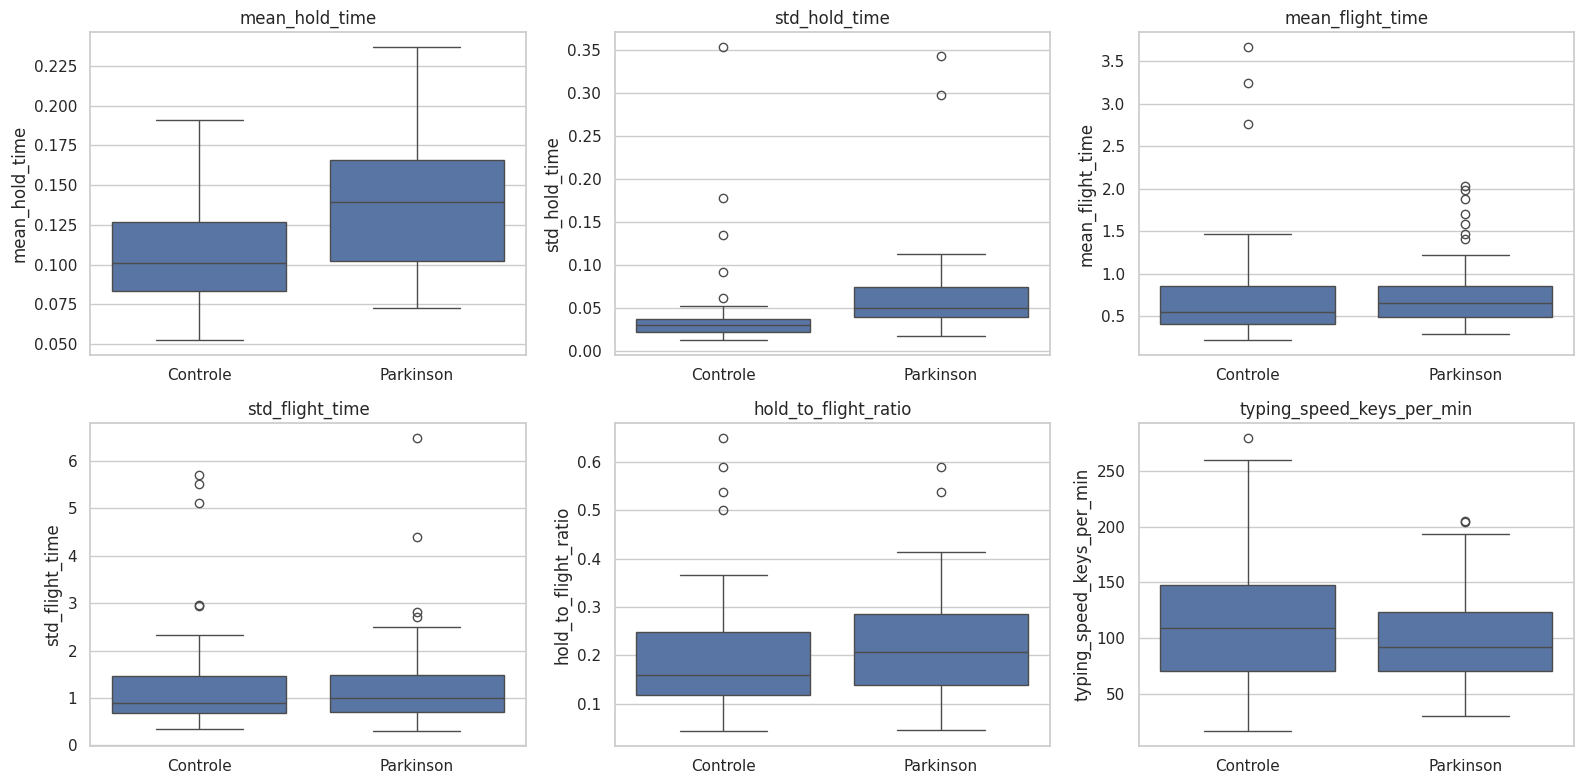

In [6]:
plot_features = ["mean_hold_time", "std_hold_time", "mean_flight_time", "std_flight_time", "hold_to_flight_ratio", "typing_speed_keys_per_min"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), plot_features):
    sns.boxplot(data=sessions, x="label", y=col, ax=ax)
    ax.set_title(col)
    ax.set_xticklabels(["Controle", "Parkinson"])
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

### Lecture des boxplots

Les boxplots montrent surtout une separation sur les variables de **hold time**: les sessions Parkinson ont tendance a presenter des temps de maintien plus eleves et plus disperses. C'est coherent avec l'hypothese motrice: bradykinesie, hesitation et variabilite du controle fin peuvent allonger ou rendre moins reguliere la pression des touches.

Les variables de **flight time** sont plus bruitees. Elles contiennent des outliers forts et semblent moins directement separees entre les classes. Cela ne veut pas dire qu'elles sont inutiles: elles peuvent aider en interaction avec d'autres features, mais elles sont moins lisibles seules.

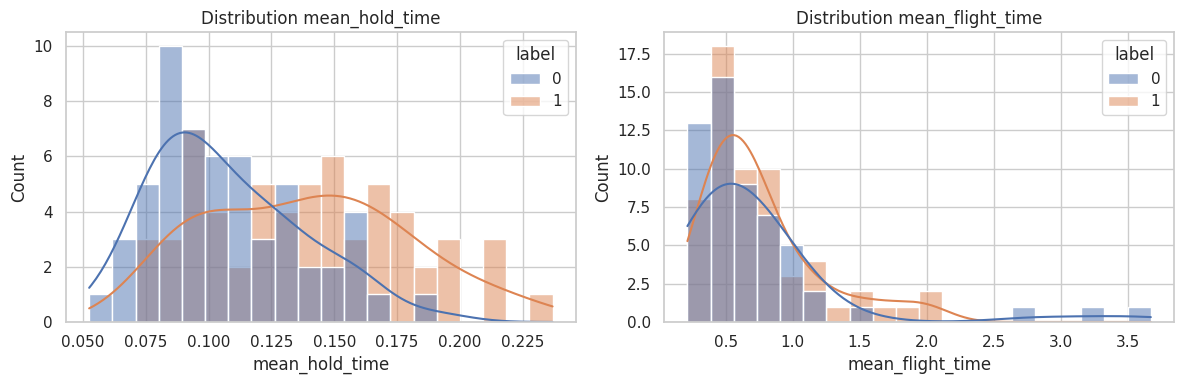

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=sessions, x="mean_hold_time", hue="label", kde=True, bins=20, ax=axes[0])
axes[0].set_title("Distribution mean_hold_time")
sns.histplot(data=sessions, x="mean_flight_time", hue="label", kde=True, bins=20, ax=axes[1])
axes[1].set_title("Distribution mean_flight_time")
plt.tight_layout()
plt.show()

### Lecture des distributions hold/flight

La distribution de `mean_hold_time` montre un decalage plus interpretable entre les deux groupes que `mean_flight_time`. Le temps de vol moyen varie beaucoup d'une session a l'autre, probablement parce qu'il depend du rythme global, des pauses et du comportement de correction.

Pour la suite, on s'attend donc a ce que PSO ou Random Forest favorise davantage des features de maintien et de dispersion plutot que le simple `mean_flight_time`.

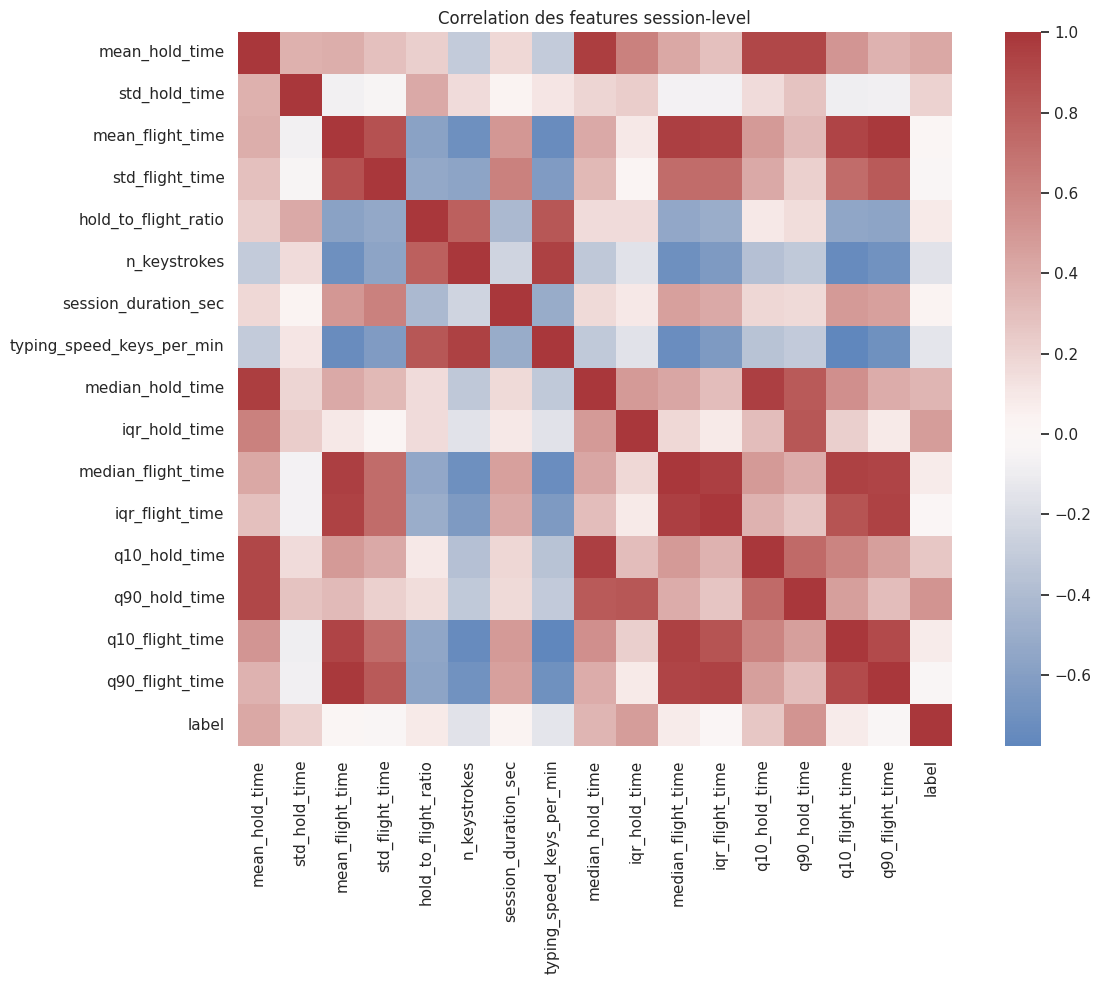

,correlation_with_label
q90_hold_time,0.514337
iqr_hold_time,0.469681
mean_hold_time,0.417020
median_hold_time,0.341364
q10_hold_time,0.262152
std_hold_time,0.208712
n_keystrokes,-0.153585
typing_speed_keys_per_min,-0.143728
hold_to_flight_ratio,0.089254
median_flight_time,0.082696


In [8]:
corr = sessions[feature_cols + ["label"]].corr(numeric_only=True)
plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="vlag", center=0, annot=False, square=True)
plt.title("Correlation des features session-level")
plt.tight_layout()
plt.show()

label_corr = corr["label"].drop("label").sort_values(key=lambda s: s.abs(), ascending=False)
display(label_corr.to_frame("correlation_with_label"))

### Lecture des correlations

La correlation avec le label confirme le signal vu dans les figures: les meilleures correlations lineaires viennent des features de hold time, notamment:

- `q90_hold_time` avec environ **0.51**;
- `iqr_hold_time` avec environ **0.47**;
- `mean_hold_time` avec environ **0.42**;
- `median_hold_time` avec environ **0.34**.

Les features de flight time ont des correlations lineaires faibles. Cela ne les exclut pas automatiquement, car un modele non lineaire peut exploiter des interactions, mais leur signal individuel est moins net.

Cette heatmap soutient l'idee d'une selection de variables: plusieurs features de hold time sont redondantes entre elles, et PSO peut aider a choisir un sous-ensemble compact.

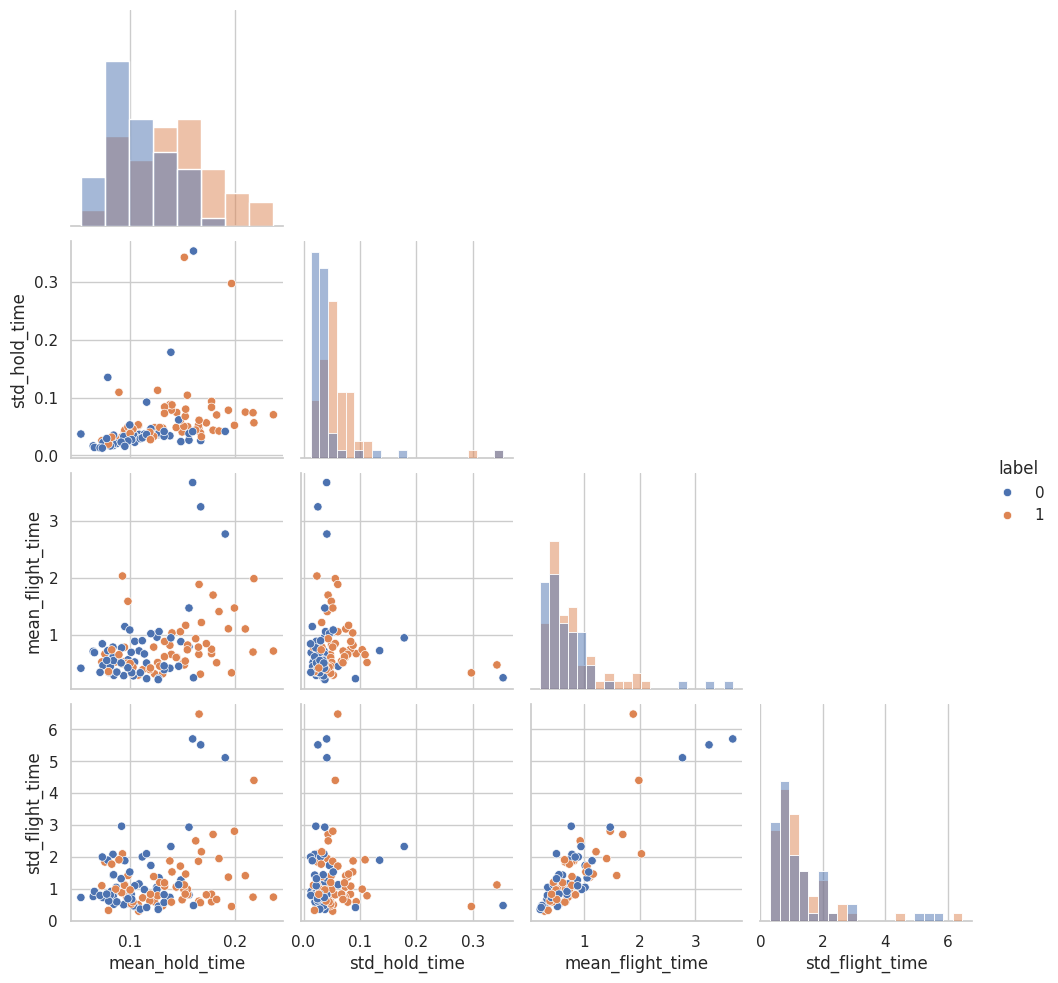

In [9]:
pair_cols = ["mean_hold_time", "std_hold_time", "mean_flight_time", "std_flight_time", "label"]
sns.pairplot(sessions[pair_cols].dropna(), hue="label", diag_kind="hist", corner=True)
plt.show()

### Lecture du pairplot

Le pairplot ne montre pas deux clusters parfaitement separables. Les classes se chevauchent, ce qui est normal avec un petit dataset humain et des mesures comportementales. On observe plutot des zones de densite differentes: certaines sessions Parkinson se situent plus haut sur les temps de maintien et leur dispersion.

Conclusion EDA: le probleme semble apprendre un signal reel, mais ce n'est pas un dataset trivial. Une accuracy proche de 99% avec une validation stricte par sujet serait suspecte ici; des scores plus modestes mais robustes sont plus credibles.

## 4. Validation et pipelines

Les pipelines suivants mettent `SMOTE` uniquement a l'interieur des folds d'entrainement. Le fold de validation reste intact, ce qui evite une fuite de donnees.

In [10]:
X = sessions[feature_cols].copy()
y = sessions["label"].astype(int).copy()
groups = sessions["pID"].astype(str).copy()

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Controle anti-fuite: aucun sujet ne doit etre present dans train et validation pour un meme fold.
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y, groups), start=1):
    train_subjects = set(groups.iloc[train_idx])
    valid_subjects = set(groups.iloc[valid_idx])
    overlap = train_subjects & valid_subjects
    print(f"Fold {fold}: train={len(train_idx)}, valid={len(valid_idx)}, subject_overlap={len(overlap)}")
    assert not overlap, f"Data leakage: subjects in both train and valid: {overlap}"

numeric_preprocess = [
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
]


def make_pipeline(model, use_smote=True):
    steps = numeric_preprocess.copy()
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)))
    steps.append(("model", model))
    return ImbPipeline(steps)

models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "SVC": SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

voting = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ("svc", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    voting="soft",
    n_jobs=-1,
)

stacking = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
        ("svc", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
    ],
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    stack_method="predict_proba",
    n_jobs=-1,
)

models["VotingClassifier"] = voting
models["StackingClassifier"] = stacking

Fold 1: train=93, valid=23, subject_overlap=0
Fold 2: train=93, valid=23, subject_overlap=0
Fold 3: train=93, valid=23, subject_overlap=0
Fold 4: train=93, valid=23, subject_overlap=0
Fold 5: train=92, valid=24, subject_overlap=0


### Controle de validation

Les cinq folds affichent `subject_overlap=0`. C'est un point central du notebook: les predictions sont evaluees sur des participants jamais vus pendant l'entrainement du fold.

Ce choix rend les scores plus bas qu'un split stratifie simple, mais beaucoup plus honnetes pour une future application ou l'utilisateur final sera forcement un nouveau sujet.

In [11]:
def evaluate_pipeline(name: str, pipeline, X_data: pd.DataFrame, y_data: pd.Series, groups_data: pd.Series):
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
    }
    scores = cross_validate(
        pipeline,
        X_data,
        y_data,
        groups=groups_data,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise",
    )
    row = {"model": name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    return row

baseline_results = []
for name, model in models.items():
    use_smote = name != "Dummy"
    pipeline = make_pipeline(model, use_smote=use_smote)
    baseline_results.append(evaluate_pipeline(name, pipeline, X, y, groups))

results_df = pd.DataFrame(baseline_results).sort_values("f1_mean", ascending=False)
display(results_df)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Dummy,0.517391,0.008696,0.517391,0.008696,1.000000,0.000000,0.681905,0.007619
3,RandomForest,0.663768,0.032277,0.705734,0.079879,0.633333,0.100000,0.657789,0.041516
1,LogisticRegression,0.630072,0.139087,0.665152,0.153735,0.600000,0.133333,0.626843,0.136309
5,StackingClassifier,0.629710,0.048307,0.658462,0.061081,0.600000,0.097183,0.623091,0.062340
2,SVC,0.638406,0.061505,0.673333,0.067165,0.583333,0.105409,0.621515,0.078205
4,VotingClassifier,0.629710,0.082888,0.666970,0.098218,0.583333,0.091287,0.618946,0.083764


### Lecture des modeles sans PSO

Sans selection de features, `RandomForest` est le meilleur modele utile avec un F1 moyen autour de **0.66**. Les modeles lineaires et SVC restent proches, mais ne dominent pas clairement.

Le `DummyClassifier` a un recall de 1.0 parce qu'il predit toujours la classe majoritaire dans cette configuration. Son F1 autour de **0.68** est trompeur: il ne detecte pas vraiment les deux classes. C'est pour cela qu'il faut regarder accuracy, precision, recall, F1 et matrice de confusion ensemble, pas un seul indicateur isole.

A ce stade, les modeles apprennent un signal, mais la performance reste limitee avec toutes les features brutes. Cela justifie l'etape PSO.

## 5. Selection de features avec Binary PSO

La fonction de fitness maximise le F1-score moyen en validation croisee groupee, avec une petite penalite sur le nombre de features selectionnees. Cette penalite pousse PSO a eviter un masque inutilement large.

In [12]:
PSO_BASE_MODEL = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)


def pso_objective(masks: np.ndarray) -> np.ndarray:
    costs = []
    n_features = len(feature_cols)
    for mask in masks:
        selected = [col for col, keep in zip(feature_cols, mask.astype(bool)) if keep]
        if not selected:
            costs.append(1.0)
            continue
        pipeline = make_pipeline(clone(PSO_BASE_MODEL), use_smote=True)
        scores = cross_validate(
            pipeline,
            X[selected],
            y,
            groups=groups,
            cv=cv,
            scoring="f1",
            n_jobs=-1,
            error_score="raise",
        )["test_score"]
        penalty = 0.02 * (len(selected) / n_features)
        costs.append((1.0 - scores.mean()) + penalty)
    return np.array(costs)

optimizer = BinaryPSO(
    n_particles=20,
    dimensions=len(feature_cols),
    options={"c1": 1.5, "c2": 1.5, "w": 0.8, "k": 8, "p": 2},
)

best_cost, best_mask = optimizer.optimize(pso_objective, iters=20, verbose=True)
selected_features = [col for col, keep in zip(feature_cols, best_mask.astype(bool)) if keep]
print(f"Best cost: {best_cost:.4f}")
print(f"Selected {len(selected_features)} / {len(feature_cols)} features:")
print(selected_features)

2026-05-06 15:49:42,330 - pyswarms.discrete.binary - INFO - Optimize for 20 iters with {'c1': 1.5, 'c2': 1.5, 'w': 0.8, 'k': 8, 'p': 2}


pyswarms.discrete.binary:   0%|          |0/20

pyswarms.discrete.binary:   0%|          |0/20, best_cost=0.261

pyswarms.discrete.binary:   5%|▌         |1/20, best_cost=0.261

pyswarms.discrete.binary:   5%|▌         |1/20, best_cost=0.296

...

pyswarms.discrete.binary:  95%|█████████▌|19/20, best_cost=0.24

pyswarms.discrete.binary: 100%|██████████|20/20, best_cost=0.24

pyswarms.discrete.binary: 100%|██████████|20/20, best_cost=0.24


2026-05-06 15:51:35,582 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.23964340007818263, best pos: [1 1 0 0 0 1 1 0 1 0 0 1 0 1 0 1]


Best cost: 0.2396
Selected 8 / 16 features:
['mean_hold_time', 'std_hold_time', 'n_keystrokes', 'session_duration_sec', 'median_hold_time', 'iqr_flight_time', 'q90_hold_time', 'q90_flight_time']


### Lecture de la selection PSO

PSO selectionne 8 features sur 16:

`mean_hold_time`, `std_hold_time`, `n_keystrokes`, `session_duration_sec`, `median_hold_time`, `iqr_flight_time`, `q90_hold_time`, `q90_flight_time`.

La selection confirme l'importance des variables de maintien (`mean`, `median`, `std`, `q90`) et garde aussi deux informations de rythme/dispersion cote flight time. Le fait que `n_keystrokes` et `session_duration_sec` soient retenues est utile pour la prediction, mais doit etre surveille: ces variables peuvent refleter le comportement pendant le protocole autant que la maladie.

Pour une future app web, il faudra idealement standardiser fortement le test de frappe afin que ces features de volume/duree ne capturent pas seulement des differences de consigne ou de motivation.

In [13]:
pso_results = []
for name, model in models.items():
    use_smote = name != "Dummy"
    pipeline = make_pipeline(model, use_smote=use_smote)
    pso_results.append(evaluate_pipeline(f"{name} + PSO", pipeline, X[selected_features], y, groups))

all_results = pd.concat([results_df, pd.DataFrame(pso_results)], ignore_index=True)
all_results = all_results.sort_values("f1_mean", ascending=False)
display(all_results)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
9,RandomForest + PSO,0.750362,0.062002,0.763185,0.078626,0.766667,0.122474,0.757366,0.071509
0,Dummy,0.517391,0.008696,0.517391,0.008696,1.000000,0.000000,0.681905,0.007619
6,Dummy + PSO,0.517391,0.008696,0.517391,0.008696,1.000000,0.000000,0.681905,0.007619
1,RandomForest,0.663768,0.032277,0.705734,0.079879,0.633333,0.100000,0.657789,0.041516
10,VotingClassifier + PSO,0.664493,0.064797,0.700303,0.075748,0.616667,0.100000,0.652279,0.079428
7,LogisticRegression + PSO,0.655797,0.092174,0.684286,0.096628,0.633333,0.124722,0.652168,0.098482
11,StackingClassifier + PSO,0.647101,0.036058,0.677359,0.054877,0.616667,0.100000,0.640016,0.058452
8,SVC + PSO,0.673551,0.073403,0.741566,0.105919,0.566667,0.097183,0.639823,0.092463
2,LogisticRegression,0.630072,0.139087,0.665152,0.153735,0.600000,0.133333,0.626843,0.136309
3,StackingClassifier,0.629710,0.048307,0.658462,0.061081,0.600000,0.097183,0.623091,0.062340


### Effet de PSO sur les resultats

La combinaison `RandomForest + PSO` monte a environ **0.75 d'accuracy** et **0.76 de F1 moyen**, soit un gain clair par rapport au Random Forest sans PSO. Les autres modeles ne profitent pas autant de la selection.

C'est un resultat interessant pour une baseline: la selection de features ameliore la generalisation par sujet, probablement en retirant du bruit et des variables redondantes. En revanche, les ecarts-types restent visibles, ce qui rappelle que le dataset est petit et que les folds dependent fortement des sujets retenus.

## 6. Matrice de confusion agregee et sauvegarde du meilleur pipeline

On selectionne le meilleur modele selon le F1-score moyen. Pour la matrice de confusion, on genere des predictions out-of-fold afin de rester coherent avec la validation groupee.

Best model: RandomForest + PSO
Features: ['mean_hold_time', 'std_hold_time', 'n_keystrokes', 'session_duration_sec', 'median_hold_time', 'iqr_flight_time', 'q90_hold_time', 'q90_flight_time']
              precision    recall  f1-score   support

    Controle       0.75      0.73      0.74        56
   Parkinson       0.75      0.77      0.76        60

    accuracy                           0.75       116
   macro avg       0.75      0.75      0.75       116
weighted avg       0.75      0.75      0.75       116



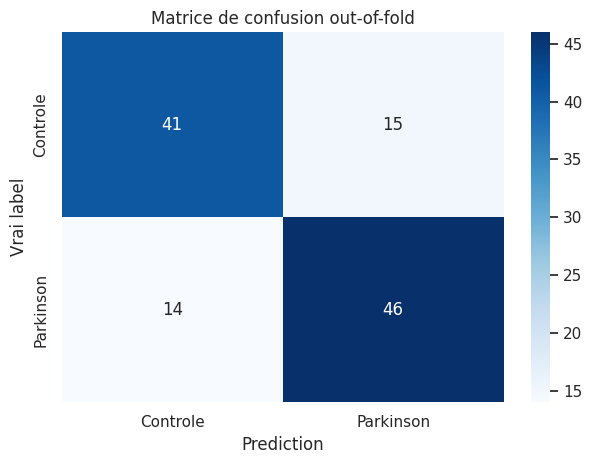

In [14]:
def out_of_fold_predictions(model, X_data: pd.DataFrame, y_data: pd.Series, groups_data: pd.Series, use_smote=True):
    preds = np.zeros(len(y_data), dtype=int)
    for train_idx, valid_idx in cv.split(X_data, y_data, groups_data):
        pipeline = make_pipeline(clone(model), use_smote=use_smote)
        pipeline.fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
        preds[valid_idx] = pipeline.predict(X_data.iloc[valid_idx])
    return preds

best_row = all_results.iloc[0]
best_name = best_row["model"]
uses_pso = best_name.endswith(" + PSO")
base_name = best_name.replace(" + PSO", "")
best_model = models[base_name]
best_features = selected_features if uses_pso else feature_cols
best_use_smote = base_name != "Dummy"

preds = out_of_fold_predictions(best_model, X[best_features], y, groups, use_smote=best_use_smote)
cm = confusion_matrix(y, preds)

print(f"Best model: {best_name}")
print(f"Features: {best_features}")
print(classification_report(y, preds, target_names=["Controle", "Parkinson"]))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Controle", "Parkinson"], yticklabels=["Controle", "Parkinson"])
plt.title("Matrice de confusion out-of-fold")
plt.xlabel("Prediction")
plt.ylabel("Vrai label")
plt.tight_layout()
plt.show()

### Lecture de la matrice de confusion

Le meilleur modele final est `RandomForest + PSO`. En predictions out-of-fold, il atteint environ:

- precision controle: **0.75**;
- recall controle: **0.73**;
- precision Parkinson: **0.75**;
- recall Parkinson: **0.77**;
- accuracy globale: **0.75**.

Le modele est donc assez equilibre: il ne gagne pas simplement en predisant une seule classe. Pour un contexte de prevention, le recall Parkinson est important, mais il n'est pas parfait. Ce prototype peut servir de signal de screening dans une demo, pas de decision medicale.

In [15]:
final_pipeline = make_pipeline(clone(best_model), use_smote=best_use_smote)
final_pipeline.fit(X[best_features], y)

artifact = {
    "pipeline": final_pipeline,
    "features": best_features,
    "model_name": best_name,
    "label_mapping": {0: "Controle", 1: "Parkinson"},
    "validation": "StratifiedGroupKFold grouped by pID; metrics from notebook cross-validation",
}

model_path = MODEL_DIR / "keyboard_dynamics_neuroqwerty_pipeline.joblib"
joblib.dump(artifact, model_path)
print(f"Saved model artifact: {model_path}")

Saved model artifact: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Hackaton/parkinson-detection/models/keyboard_dynamics_neuroqwerty_pipeline.joblib


### Export du pipeline

L'artefact `models/keyboard_dynamics_neuroqwerty_pipeline.joblib` contient le pipeline complet: imputation, scaling, SMOTE, modele final et liste des features retenues. C'est pratique pour une future API ou interface web, a condition de recalculer exactement les memes features depuis le module de capture clavier.

La prochaine etape technique devrait etre de sortir le feature engineering du notebook vers un module Python partage, pour eviter une divergence entre entrainement et inference web.

## 7. Limites et prochaines etapes

Limites principales:
- Le dataset est petit en nombre de sujets: les scores peuvent varier fortement selon les folds.
- Les resultats ne sont pas cliniques et ne doivent pas etre interpretes comme un diagnostic.
- Le papier recent rapporte 621 lignes deja agregees; ici on reconstruit les features depuis MIT-CS1PD/MIT-CS2PD brut, donc les scores ne sont pas directement comparables.
- Un split stratifie simple serait probablement trop optimiste, car un meme sujet pourrait se retrouver dans train et test.
- Les donnees viennent de conditions controlees et ne garantissent pas une generalisation a un site web grand public.

Prochaines etapes:
- stabiliser les features qui seront collectees dans une future interface web;
- tester une evaluation LOSO pour mesurer la robustesse sujet par sujet;
- ajouter SHAP ou permutation importance pour expliquer les predictions;
- connecter ce pipeline a une fusion tardive multimodale avec les autres modalites du projet.